Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Models...
✅ Models loaded successfully.


Saving 11.jpg to 11 (1).jpg


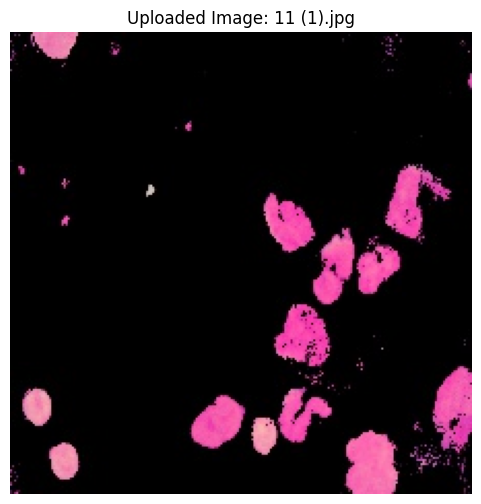


--- HYBRID PREDICTION RESULT ---
FINAL CLASSIFICATION: ALLNeg (Healthy)
CONFIDENCE: 78.82%
------------------------------
CNN Branch Confidence: 34.27%
EfficientNet Branch Confidence: 8.08%


In [14]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from google.colab import drive, files

# Fix potential image loading issues
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. MOUNT GOOGLE DRIVE
drive.mount('/content/drive')

# 2. LOAD SAVED MODELS
# Paths derived from your training notebooks
CNN_PATH = '/content/drive/MyDrive/Research/Results_cnn/best_leukemia_model.keras'
EFFNET_PATH = '/content/drive/MyDrive/Research/Results_efficientnet/best_leukemia_model_efficientnet.keras'

print("Loading Models...")
cnn_model = tf.keras.models.load_model(CNN_PATH)
effnet_model = tf.keras.models.load_model(EFFNET_PATH)
print("✅ Models loaded successfully.")

# 3. PREDICTION & DISPLAY FUNCTION
def run_hybrid_prediction(image_path):
    # Display the uploaded image
    img_display = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.axis('off')
    plt.title(f"Uploaded Image: {os.path.basename(image_path)}")
    plt.show()

    # Preprocess for CNN (128x128)
    img_cnn = img_display.convert('RGB').resize((128, 128))
    img_cnn_arr = np.array(img_cnn) / 255.0
    img_cnn_arr = np.expand_dims(img_cnn_arr, axis=0)

    # Preprocess for EfficientNet (224x224)
    img_eff = img_display.convert('RGB').resize((224, 224))
    img_eff_arr = np.array(img_eff) / 255.0
    img_eff_arr = np.expand_dims(img_eff_arr, axis=0)

    # Get branch predictions
    prob_cnn = cnn_model.predict(img_cnn_arr, verbose=0)[0][0]
    prob_eff = effnet_model.predict(img_eff_arr, verbose=0)[0][0]

    # Hybrid logic (Average of both sigmoid outputs)
    final_prob = (prob_cnn + prob_eff) / 2
    result_label = "ALLPos (Leukemia)" if final_prob >= 0.5 else "ALLNeg (Healthy)"
    confidence = final_prob if final_prob >= 0.5 else (1 - final_prob)

    # Show Results
    print(f"\n--- HYBRID PREDICTION RESULT ---")
    print(f"FINAL CLASSIFICATION: {result_label}")
    print(f"CONFIDENCE: {confidence:.2%}")
    print("-" * 30)
    print(f"CNN Branch Confidence: {prob_cnn:.2%}")
    print(f"EfficientNet Branch Confidence: {prob_eff:.2%}")

# 4. MANUAL UPLOAD TRIGGER
uploaded = files.upload()

for filename in uploaded.keys():
    run_hybrid_prediction(filename)